Data cleaning involves identifying and removing any missing, duplicate or irrelevant data.

Raw data (log file, transactions, audio /video recordings, etc) is often noisy, incomplete and inconsistent which can negatively impact the accuracy of the model.
The goal of data cleaning is to ensure that the data is accurate, consistent and free of errors.
Clean datasets are also important in EDA (Exploratory Data Analysis), which enhances the interpretability of data so that the right actions can be taken based on insights.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('Titanic-Dataset.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Step 2: Check for Duplicate Rows
df.duplicated(): Returns a boolean Series indicating duplicate rows.


In [2]:
df.duplicated()


0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

Step 3: Identify Column Data Types
List comprehension with .dtype attribute to separate categorical and numerical columns.
object dtype: Generally used for text or categorical data.

In [3]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


Step 4: Count Unique Values in the Categorical Columns
df[cat_col].nunique(): Returns count of unique values per column.

In [4]:
df[cat_col].nunique()

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

Step 5: Calculate Missing Values as Percentage
df.isnull(): Detects missing values, returning boolean DataFrame.
Sum missing across columns, normalize by total rows and multiply by 100.

In [5]:
round((df.isnull().sum() / df.shape[0]) * 100, 2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

Step 6: Drop Irrelevant or Data-Heavy Missing Columns
df.drop(columns=[]): Drops specified columns from the DataFrame.
df.dropna(subset=[]): Removes rows where specified columns have missing values.
fillna(): Fills missing values with specified value (e.g., mean).

In [6]:
df1 = df.drop(column ])
df1.dropna(subset=['Embarked'], inplace=True)
df1['Age'] = df1['Age'].fillna(df1['Age'].mean())


Step 7: Detect Outliers with Box Plot
matplotlib.pyplot.boxplot(): Displays distribution of data, highlighting median, quartiles and outliers.
plt.show(): Renders the plot

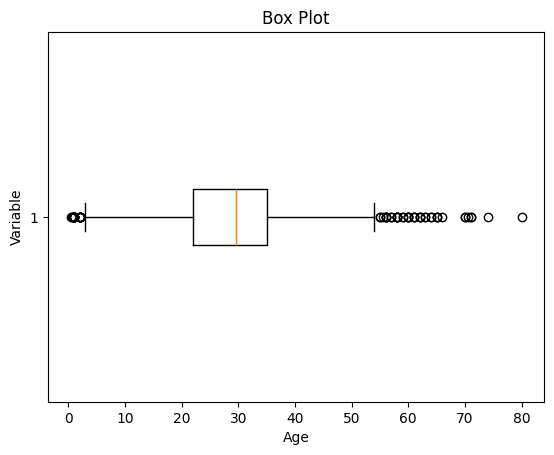

In [8]:
import matplotlib.pyplot as plt

plt.boxplot(df1['Age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()

Step 8: Calculate Outlier Boundaries and Remove Them
Calculate mean and standard deviation (std) using df['Age'].mean() and df['Age'].std().
Define bounds as mean ± 2 * std for outlier detection.
Filter DataFrame rows within bounds using Boolean indexing.

In [2]:
mean = df1['Age'].mean()
std = df1['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

df2 = df1[(df1['Age'] >= lower_bound) & (df1['Age'] <= upper_bound)]


NameError: name 'df1' is not defined

Step 9: Impute Missing Data Again if Any
fillna() applied again on filtered data to handle any remaining missing values.

In [10]:
df3 = df2.fillna(df2['Age'].mean())
df3.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

Step 10: Recalculate Outlier Bounds and Remove Outliers from the Updated Data
mean = df3['Age'].mean(): Calculates the average (mean) value of the Age column in the DataFrame df3.
std = df3['Age'].std(): Computes the standard deviation (spread or variability) of the Age column in df3.
lower_bound = mean - 2 * std: Defines the lower limit for acceptable Age values, set as two standard deviations below the mean.
upper_bound = mean + 2 * std: Defines the upper limit for acceptable Age values, set as two standard deviations above the mean.
df4 = df3[(df3['Age'] >= lower_bound) & (df3['Age'] <= upper_bound)]: Creates a new DataFrame df4 by selecting only rows where the Age value falls between the lower and upper bounds, effectively removing outlier ages outside this range.

In [11]:
mean = df3['Age'].mean()
std = df3['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

df4 = df3[(df3['Age'] >= lower_bound) & (df3['Age'] <= upper_bound)]

Lower Bound : 8.978989004171453
Upper Bound : 49.30395961288914


Step 11: Data validation and verification
Data validation and verification involve ensuring that the data is accurate and consistent by comparing it with external sources or expert knowledge. 

For the machine learning prediction we separate independent and target features
Here we will consider only 'Sex' 'Age' 'SibSp', 'Parch' 'Fare' 'Embarked' only as the independent features
Survived as target variables because PassengerId will not affect the survival rate

In [12]:
X = df3[['Pclass','Sex','Age', 'SibSp','Parch','Fare','Embarked']]
Y = df3['Survived']


Step 12: Data formatting
Data formatting involves converting the data into a standard format or structure that can be easily processed by the algorithms or models used for analysis. Here we will discuss commonly used data formatting techniques i.e. Scaling and Normalization.

1. Min-Max Scaling: Scaling involves transforming the values of features to a specific range. Min-Max scaling rescales the values to a specified range, typically between 0 and 1. It preserves the original distribution and ensures that the minimum value maps to 0 and the maximum value maps to 1.
2. 

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

num_col_ = [col for col in X.columns if X[col].dtype != 'object']
x1 = X
x1[num_col_] = scaler.fit_transform(x1[num_col_])
x1.head()


C:\Users\CSPAD\AppData\Local\Temp\ipykernel_14600\3885700350.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x1[num_col_] = scaler.fit_transform(x1[num_col_])


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,male,0.349515,0.125,0.0,0.014151,S
1,0.0,female,0.660194,0.125,0.0,0.139136,C
2,1.0,female,0.427184,0.000,0.0,0.015469,S
3,0.0,female,0.601942,0.125,0.0,0.103644,S
4,1.0,male,0.601942,0.000,0.0,0.015713,S


Standardization (Z-score scaling): Standardization transforms the values to have a mean of 0 and a standard deviation of 1. It centers the data around the mean and scales it based on the standard deviation. Standardization makes the data more suitable for algorithms that assume a Gaussian distribution or require features to have zero mean and unit variance.

Z = (X - μ) / σ

Where,

X = Data
μ = Mean value of X
σ = Standard deviation of X